In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm
%matplotlib inline

# Complete Guide: ML Self-Study Notebook Concepts

This notebook covers fundamental **probabilistic machine learning** and **Bayesian statistics**.

---

## **Exercise 1: Maximum Likelihood Estimation (MLE)**

**What's the Problem?**
You have data that looks normally distributed (bell-shaped), but you don't know the parameters (mean and standard deviation).

**The Solution - MLE:**
- **Mean estimate (μ̂)**: Just take the average of all your data
- **Std deviation estimate (σ̂)**: Take the standard deviation of your data

**Why?** These are the parameters that make your observed data most likely to occur.

**In code:**

```python
mu_hat = data.mean()      # Best guess for average
sigma_hat = data.std()    # Best guess for spread
```



**Visualization:** Plot a histogram of your data and overlay the Gaussian curve — does it fit well?

---

## **Exercise 2: Naive Bayes Classifier** 

**The Problem:** Predict poker game outcomes (who has the best hand) based on observed features.

**Key Idea - Bayes' Rule:**
$$P(\text{BestHand} | \text{Evidence}) = \frac{P(\text{Evidence} | \text{BestHand}) \times P(\text{BestHand})}{P(\text{Evidence})}$$

**"Naive" means:** Assume all features are independent (simpler but not always true)

**The Process:**
1. **Calculate priors**: What percentage of games does each player win overall?
   ```python
   p = df[(df.BH == c)].shape[0] / len(df)  # Base probability
   ```

2. **Calculate likelihoods**: For each feature (cards changed, hand strength), multiply probabilities:
   ```python
   num = df[(df.BH == c) & (df[feat] == evidence[feat])].shape[0]
   p *= num / df[df.BH == c].shape[0]  # How likely this evidence given outcome
   ```

3. **Normalize**: Make probabilities sum to 1
   ```python
   post[c] = post[c] / Z  # Z is the sum of all unnormalized probabilities
   ```

**Potential Issue:** If a feature doesn't exist in the training data, you get probability 0, which breaks everything. **Solution:** Use smoothing (add fake examples).

---

## **Exercise 3: EM Algorithm (Expectation-Maximization)**

**The Problem:** You have missing data (marked with "?") — how do you learn from it?

**The Algorithm has 2 Steps:**

### **E-Step (Expectation):**
Guess the missing values using soft probabilities

> For each missing value:
> - Calculate: What's the probability it's value X vs value Y?
> - Assign these probabilities to the data




Example: If Pr is missing and Bt=pos, Ut=neg:
- Guess: P(Pr=yes | Bt=pos, Ut=neg) = 0.7
- Guess: P(Pr=no | Bt=pos, Ut=neg) = 0.3

### **M-Step (Maximization):**
Update model parameters using the soft assignments

> For each probability:
> - Count: weighted sum of rows where condition is true
> - Divide by: weighted sum of all rows where parent condition is true



**Why?** Repeat these 2 steps until answers stabilize (convergence).

---

## **Exercise 4: Bayesian Inference with Custom Prior**

**The Setup - A Thumbtack Experiment:**
You flip a thumbtack and want to learn P(lands on point up).

**The Prior:** A custom triangular distribution (peaks at 0.5)
- If θ ≤ 0.5: f(θ) = θ
- If θ > 0.5: f(θ) = 1 - θ

**Key Steps:**

1. **Normalize the Prior:**
   - Calculate total area under the curve = 1/4
   - Multiply by C = 4 to make total area = 1
   ```python
   C = 1 / area  # Normalization constant
   ```

2. **Apply Bayes' Rule:**
   ```
   Posterior ∝ Likelihood × Prior
   ```
   - Likelihood for "up": just θ
   - Multiply by normalized prior

3. **Normalize the Posterior:**
   - Calculate new area, divide by it

**Challenge:** The prior strongly pushes belief toward θ = 0.5, even after seeing data!

---

## **Exercise 5: Beta Distribution Prior**

**Why Beta?** 
- Natural choice for probabilities (values between 0 and 1)
- **Conjugate prior** — posterior is also Beta! (mathematically convenient)

**Beta(a, b) parameters mean:**
- **a**: Related to number of successes seen
- **b**: Related to number of failures seen
- Higher values = sharper peak

**The Magic - Updating is Simple:**

> After seeing one "up" flip:
> - Before: Beta(2, 2)
> - After:  Beta(2+1, 2) = Beta(3, 2)




Just add to the alpha parameter!

**Posterior predictive:** "If I flip again, what's probability of up?"
- Simple answer: $\frac{a_{posterior}}{a_{posterior} + b_{posterior}}$
- For Beta(3, 2): = 3/5 = 0.6

---

## **Quick Concept Hierarchy**



```python
┌─ Estimation (Exercise 1)
│  ├─ Find parameters that fit data
│  └─ MLE: Pick parameters that maximize likelihood
│
├─ Classification (Exercise 2)
│  ├─ Predict class given features
│  └─ Naive Bayes: Use Bayes' rule + independence assumption
│
├─ Missing Data (Exercise 3)
│  ├─ Learn from incomplete information
│  └─ EM: Alternately guess missing values & update model
│
└─ Bayesian Inference (Exercises 4-5)
   ├─ Combine prior belief + observations
   ├─ Use Bayes' rule to get posterior
   └─ Beta distribution: Clean closed-form updates
```

# Part 1

## Exercise 1

Consider the data set below

In [21]:
data = np.array([4.04078064, -0.55665445, 3.05080334, 5.08400317, 2.72089663, 0.71922335, 0.95069126, 5.43223656, 3.50298766, -1.69666696, 0.16887197, 0.97921115, 4.81828023, 2.13361239, 2.31649532, 2.45398909, 2.95186638, 0.35927233, 1.53276119, 1.51244625, 2.05198596, -0.10338973, 2.18330019, 1.20449377, 1.77198419, 2.36079822, 4.24525693, 1.28167319, -0.4782344 , 2.15987517, 1.04436119, -3.31367483, 1.90677577, -1.52585791, 1.30861677, 3.92755598, 5.28340674, 2.46339939, 2.92340074, 6.86935904, 4.36460648, 4.31874289, 3.4310631 , 4.56743957, 1.89164429, 3.07432364, -1.09259307, 0.20645733, 1.9716586 , 0.48545271, 0.95117389, 1.17221689, 4.56967222, 1.00717303, 5.42222525, 3.16312747, 0.85955611, 2.1542952 , 3.32612246, 3.12462947, 0.4495974 , 1.6291549 , 1.31738387, 2.73270522, 0.40173961, 1.66718506, -2.60436878, 3.89440908, 2.06121341, 0.65197735, 5.40756812, 7.0944758 , 0.88894319, 0.96374457, -1.26270571, 2.19074211, 0.06566279, 2.01504511, 4.42887827, -0.71989433, 4.0375403 , 5.5868948 , 4.05289467, 1.25946927, -1.1316249 , -0.35446895, 6.1372851 , 0.14735692, 5.40410798, 5.33778763, 5.54798016, 3.39152955, 2.3835751 , 0.03465975, 0.81116816, 4.39280317, 1.85958392, 2.27926744, 1.51646355, 2.66025771])

Assume a Gaussian distribution for the data.
* Calculate maximum likelihood estimates for the parameters
* Visualize the data and the model

mu_hat: 2.1763716977
sigma_hat: 2.083571329932802


(array([0.01921571, 0.02882356, 0.05764713, 0.12490211, 0.20176495,
        0.20176495, 0.1056864 , 0.1056864 , 0.08647069, 0.02882356]),
 array([-3.31367483, -2.27285977, -1.2320447 , -0.19122964,  0.84958542,
         1.89040048,  2.93121555,  3.97203061,  5.01284567,  6.05366074,
         7.0944758 ]),
 <BarContainer object of 10 artists>)

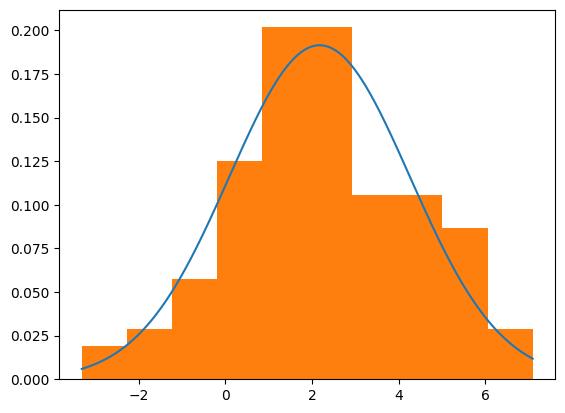

In [22]:
x = np.linspace(data.min(), data.max(), 1000) 

mu_hat = data.mean()
sigma_hat = data.std()
print(f"mu_hat: {mu_hat}")
print(f"sigma_hat: {sigma_hat}")

y = norm.pdf(x,mu_hat, sigma_hat)
plt.plot(x,y)
plt.hist(data, density=True)

## Exercise 2 

Consider a poker game consisting of two rounds, and where each player is initially dealt three cards. During the first round all three cards can be changed (FC), but during the second round at most two cards can be changed (SC). When deciding on whether to call or fold you can taken into account the number of cards changed by your opponent as well as your current hand (MH). After playing 20 games we have the results in Table 1, where BH shows who has the best hand.

In [23]:
df = pd.read_csv('./poker_data.csv')
print(df)

      BH   MH  FC  SC
0     op   no   3   1
1     op   1a   2   1
2   draw   2v   1   1
3     me   2a   1   1
4   draw   fl   1   1
5     me   st   3   2
6     me   3v   1   1
7     me  sfl   1   0
8     op   no   0   0
9     op   1a   3   2
10  draw   2v   2   1
11    me   2v   3   2
12    op   2v   1   1
13    op   2v   3   0
14    me   2v   3   2
15  draw   no   3   2
16  draw   2v   1   1
17    op   fl   1   1
18    op   no   3   2
19    me   1a   3   2


* Construct a naive Bayes classifier for the poker domain. 
* Use the data cases to learn the maximum likelihood parameters in the model; if you feel comfortable with the estimation procedure, you only need to estimate the probabilities required for solving the exercise below. 
* What is the posterior distribution of BH given MH=1a, FC=1, and SC=1? 
* Do you see any potential issues with the posterior and how could you address it?

In [24]:
features = ["MH", "FC", "SC"]
# you already made priors in d

evidence = {"MH": "1a", "FC": 1, "SC": 1}
player_classes = ["op", "me", "draw"]

post = {}

for player in player_classes:
    # What percentage of games does each player win overall?
    p = df[(df.BH == player)].shape[0] / len(df)

    for feat in features:
        # For each feature (cards changed, hand strength), multiply probabilities
        num = df[(df.BH == player) & (df[feat] == evidence[feat])].shape[0]
        den = df[df.BH == player].shape[0]
        p *= num / den  # multiply likelihoods

    post[player] = p

print(f"pre-norm: {post}")

# Normalize
Z = sum(post.values())
for player in player_classes:
    post[player] = post[player] / Z

print(f"post-norm: {post}")
    


pre-norm: {'op': 0.0125, 'me': 0.0061224489795918356, 'draw': 0.0}
post-norm: {'op': 0.6712328767123288, 'me': 0.32876712328767116, 'draw': 0.0}


## Exercise 3

Perform one more iteration of the EM-algorithm in the example on Slide 23. You may consider using Python to calculate the required probabilities. 

In [30]:
import pandas as pd
import numpy as np

cases = pd.read_csv('./cases.csv')
print(cases)

# ============================================
# E-STEP: Assign soft probabilities
# ============================================

def expectation_step(p_pr, p_bt_given_pr, p_ut_given_pr):
    """
    For each row, compute probability of missing values given observed values
    Store soft assignments for missing Pr and Ut
    """
    for idx, row in cases.iterrows():
        pr_val = row['Pr']
        bt_val = row['Bt']
        ut_val = row['Ut']
        
        # Handle missing Pr
        if pr_val == "?":
            # Compute P(Pr=yes|Bt,Ut) for rows where Ut is known
            if ut_val != "?":
                p_yes = (p_pr['yes'] * 
                         p_bt_given_pr['yes'].get(bt_val, 0.5) * 
                         p_ut_given_pr['yes'].get(ut_val, 0.5))
                p_no = (p_pr['no'] * 
                        p_bt_given_pr['no'].get(bt_val, 0.5) * 
                        p_ut_given_pr['no'].get(ut_val, 0.5))
            else:
                # Ut also missing: marginalize over it
                p_yes = (p_pr['yes'] * 
                         p_bt_given_pr['yes'].get(bt_val, 0.5) *
                         0.5)  # Average over Ut
                p_no = (p_pr['no'] * 
                        p_bt_given_pr['no'].get(bt_val, 0.5) *
                        0.5)
            
            total = p_yes + p_no
            cases.loc[idx, 'p_pr_yes'] = p_yes / total
            cases.loc[idx, 'p_pr_no'] = p_no / total
        else:
            # Known Pr value
            cases.loc[idx, 'p_pr_yes'] = 1.0 if pr_val == 'yes' else 0.0
            cases.loc[idx, 'p_pr_no'] = 0.0 if pr_val == 'yes' else 1.0
        
        # Handle missing Ut (similar logic)
        if ut_val == "?":
            pr_val_known = pr_val if pr_val != "?" else "yes"  # Use mode for unknown Pr
            p_ut_yes = (p_ut_given_pr.get(pr_val_known, {}).get('pos', 0.5))
            p_ut_no = (p_ut_given_pr.get(pr_val_known, {}).get('neg', 0.5))
            
            total = p_ut_yes + p_ut_no
            cases.loc[idx, 'p_ut_pos'] = p_ut_yes / total
            cases.loc[idx, 'p_ut_neg'] = p_ut_no / total
        else:
            cases.loc[idx, 'p_ut_pos'] = 1.0 if ut_val == 'pos' else 0.0
            cases.loc[idx, 'p_ut_neg'] = 0.0 if ut_val == 'pos' else 1.0

# ============================================
# M-STEP: Update parameters
# ============================================

def maximization_step():
    """Update all probabilities based on soft assignments"""
    
    n = len(cases)
    
    # P(Pr=yes)
    p_pr_yes = cases['p_pr_yes'].sum() / n
    
    # P(Bt=pos | Pr=yes)
    bt_pos_given_yes_num = (cases[cases.Bt == 'pos']['p_pr_yes'].sum())
    bt_pos_given_yes_den = cases['p_pr_yes'].sum()
    p_bt_pos_given_yes = bt_pos_given_yes_num / bt_pos_given_yes_den if bt_pos_given_yes_den > 0 else 0.5
    
    # P(Bt=pos | Pr=no)
    bt_pos_given_no_num = (cases[cases.Bt == 'pos']['p_pr_no'].sum())
    bt_pos_given_no_den = cases['p_pr_no'].sum()
    p_bt_pos_given_no = bt_pos_given_no_num / bt_pos_given_no_den if bt_pos_given_no_den > 0 else 0.5
    
    # P(Ut=pos | Pr=yes)
    ut_pos_given_yes_num = (cases[cases.Ut == 'pos']['p_pr_yes'].sum() + 
                            cases[cases.Ut == '?']['p_ut_pos'].mul(cases['p_pr_yes']).sum())
    ut_pos_given_yes_den = cases['p_pr_yes'].sum()
    p_ut_pos_given_yes = ut_pos_given_yes_num / ut_pos_given_yes_den if ut_pos_given_yes_den > 0 else 0.5
    
    # P(Ut=pos | Pr=no)
    ut_pos_given_no_num = (cases[cases.Ut == 'pos']['p_pr_no'].sum() + 
                           cases[cases.Ut == '?']['p_ut_pos'].mul(cases['p_pr_no']).sum())
    ut_pos_given_no_den = cases['p_pr_no'].sum()
    p_ut_pos_given_no = ut_pos_given_no_num / ut_pos_given_no_den if ut_pos_given_no_den > 0 else 0.5
    
    new_p_pr = {'yes': p_pr_yes, 'no': 1 - p_pr_yes}
    new_p_bt_given_pr = {
        'yes': {'pos': p_bt_pos_given_yes, 'neg': 1 - p_bt_pos_given_yes},
        'no': {'pos': p_bt_pos_given_no, 'neg': 1 - p_bt_pos_given_no}
    }
    new_p_ut_given_pr = {
        'yes': {'pos': p_ut_pos_given_yes, 'neg': 1 - p_ut_pos_given_yes},
        'no': {'pos': p_ut_pos_given_no, 'neg': 1 - p_ut_pos_given_no}
    }
    
    return new_p_pr, new_p_bt_given_pr, new_p_ut_given_pr

# ============================================
# RUN EM
# ============================================

p_pr = {'yes': 0.5, 'no': 0.5}
p_bt_given_pr = {'yes': {'pos': 0.5, 'neg': 0.5}, 'no': {'pos': 0.5, 'neg': 0.5}}
p_ut_given_pr = {'yes': {'pos': 0.5, 'neg': 0.5}, 'no': {'pos': 0.5, 'neg': 0.5}}

for i in range(6):
    print(f"=== Iteration {i} ===")
    expectation_step(p_pr, p_bt_given_pr, p_ut_given_pr)
    print(cases[['Pr', 'Bt', 'Ut', 'p_pr_yes', 'p_ut_pos']])
    print()

    p_pr, p_bt_given_pr, p_ut_given_pr = maximization_step()
    print(f"P(Pr=yes): {p_pr['yes']:.3f}")
    print(f"P(Bt=pos|Pr=yes): {p_bt_given_pr['yes']['pos']:.3f}")
    print(f"P(Ut=pos|Pr=yes): {p_ut_given_pr['yes']['pos']:.3f}")

    Pr   Bt   Ut
0    ?  pos  pos
1  yes  neg  pos
2  yes  pos    ?
3  yes  pos  neg
4    ?  neg    ?
=== Iteration 0 ===
    Pr   Bt   Ut  p_pr_yes  p_ut_pos
0    ?  pos  pos       0.5       1.0
1  yes  neg  pos       1.0       1.0
2  yes  pos    ?       1.0       0.5
3  yes  pos  neg       1.0       0.0
4    ?  neg    ?       0.5       0.5

P(Pr=yes): 0.800
P(Bt=pos|Pr=yes): 0.625
P(Ut=pos|Pr=yes): 0.562
=== Iteration 1 ===
    Pr   Bt   Ut  p_pr_yes  p_ut_pos
0    ?  pos  pos  0.789474    1.0000
1  yes  neg  pos  1.000000    1.0000
2  yes  pos    ?  1.000000    0.5625
3  yes  pos  neg  1.000000    0.0000
4    ?  neg    ?  0.750000    0.5625

P(Pr=yes): 0.908
P(Bt=pos|Pr=yes): 0.614
P(Ut=pos|Pr=yes): 0.611
=== Iteration 2 ===
    Pr   Bt   Ut  p_pr_yes  p_ut_pos
0    ?  pos  pos  0.913929  1.000000
1  yes  neg  pos  1.000000  1.000000
2  yes  pos    ?  1.000000  0.611051
3  yes  pos  neg  1.000000  0.000000
4    ?  neg    ?  0.875000  0.611051

P(Pr=yes): 0.958
P(Bt=pos|Pr=yes): 0.60

## Exercise 4

In the thumbtack experiment, let the *unnormalized*
prior distribution for $\theta$ be

$$f(\theta) =
\begin{cases}
\theta\text{ if }\theta \le 1/2\\
(1-\theta)\text{ if }1/2\le \theta \le 1
\end{cases}
$$

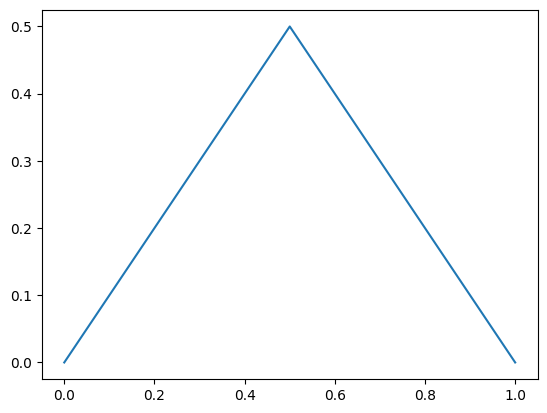

In [34]:
x = np.linspace(0,1,10000)
y = np.array([xp if xp <= 0.5 else (1-xp) for xp in x])
plt.plot(x,y)
plt.show()

* What is the normalization constant for the prior distribution?
* Assume that we have performed one experiment resulting in $up$. What is now the posterior distribution for
$\theta$? Comparing your result with the prior distribution, do you see any challenges with the current model specification? 

In [33]:
import sympy as sp

theta = sp.symbols("theta", real=True)

# Unnormalized prior f(theta)
f = sp.Piecewise(
    (theta, theta <= sp.Rational(1, 2)),
    (1 - theta, True)
)

# 1) Normalize prior: p(theta) = C * f(theta)
area = sp.integrate(f, (theta, 0, 1))
print(f"Total area under f: {area}")
C = 1 / area  
print(f"C = {C}")
p_prior = C * f

# 2) Likelihood for one observation "up"
lik_up = theta
print(f"Likelihood {lik_up}")

# 3) Unnormalized posterior
p_post_unnorm = sp.simplify(lik_up * p_prior)

# 4) Normalize posterior
Z = sp.integrate(p_post_unnorm, (theta, 0, 1))
print(f"Z = {Z}")
p_post = sp.simplify(p_post_unnorm / Z)

print("Prior (normalized):", p_prior)
print("Posterior:", p_post)

Total area under f: 1/4
C = 4
Likelihood theta
Z = 1/2
Prior (normalized): 4*Piecewise((theta, theta <= 1/2), (1 - theta, True))
Posterior: Piecewise((8*theta**2, theta <= 1/2), (8*theta*(1 - theta), True))


Step 1: Start with a shape

You have f(theta) = a piecewise shape, but it's NOT a valid probability yet (just a shape).

Step 2: Make it a valid probability (normalize the prior)

Find the area under the curve: 1/4
To turn this into a valid probability, multiply by C = 4 (so area = 1)
Now p(theta) = 4 * f(theta) is a proper probability ✓

Step 3: Use your observation (likelihood)

You flipped the thumbtack once and got "up" ✓
For Bernoulli: if you got "up", the likelihood is just theta
(If theta = 0.7, observing "up" is more likely than if theta = 0.2)

Step 4: Combine prior + likelihood (Bayes rule)

New shape = prior shape × likelihood shape
likelihood * prior = theta * 4*f(theta) ← this is NOT normalized yet

Step 5: Normalize the posterior

Find the area under this new shape: Z = 1/2
Divide by Z to make area = 1
Now you have the posterior ✓

## Exercise 5

Reconsider the thumbtack model above, but replace the prior distribution over $\theta$ and a Beta distribution chosing suitable hyperparameters of your own chosing.

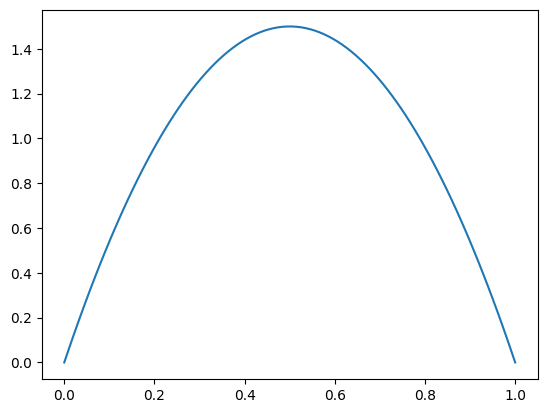

In [28]:
x = np.linspace(0,1,100)
y = beta.pdf(x,2,2)
plt.plot(x,y)

* What is the posterior distribution after seeing *pin up*? 

* How does the functional form compare to the posteror under the original prior distribution?

* How could you summarize the posterior distribution?

* Calculate the posterior predictive distribtion?

Prior: Beta(2, 2)
Unnormalized posterior shape: theta**2*(1 - theta)
Posterior: Beta(3, 2)
Posterior shape: theta^2 * (1-theta)^1


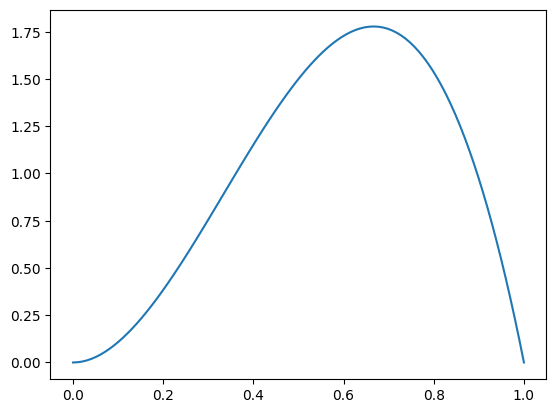

In [29]:
import sympy as sp

theta = sp.symbols("theta", real=True, positive=True)

# Choose hyperparameters for Beta(a, b)
a = 2 
b = 2

print(f"Prior: Beta({a}, {b})")

# Beta prior: p(theta) = theta^(a-1) * (1-theta)^(b-1) / B(a,b)
# (sympy's beta.pdf handles the normalization)
p_prior_unnorm = theta**(a-1) * (1-theta)**(b-1)

# Likelihood: theta (same as Exercise 4)
lik_up = theta

# Unnormalized posterior
p_post_unnorm = sp.simplify(lik_up * p_prior_unnorm)
print(f"Unnormalized posterior shape: {p_post_unnorm}")

# NEW HYPERPARAMETERS after seeing "up"
a_post = a + 1  # Add 1 for the success (up)
b_post = b      # No failures, so b stays the same

print(f"Posterior: Beta({a_post}, {b_post})")
print(f"Posterior shape: theta^{a_post-1} * (1-theta)^{b_post-1}")

y = beta.pdf(x,a_post,b_post)
plt.plot(x,y)